In [57]:
import pandas as pd
import os
import numpy as np
def processMain(N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))
    
    # Use the next line for finished ins
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_A3_0_15_N"+str(N)+"_")]
    # prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_15_N"+str(N)+"_")]
    #Use the one below for Iter
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"_")]
    # print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        # Use the next line for finished ins
        df = pd.read_csv(''+filename, sep=';', names=['iiter','emptycol','total_time','b','ObjVal','LB','x_sol', 'Kbar', 'K'], header=None)
        # Use the one below for Iter collection
        # df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        df['Ins'] = split
        df['Ins'] = df['Ins'].astype(int)
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output
N =30
df_main = processMain(N)
df_main
# df_main.to_csv("N"+str(N)+"_15_main_df.csv")
# df_main_less5 = df_main[df_main.total_time < 300]
# df_main_less1hour = df_main[(df_main.total_time < 3600) & (df_main.total_time >=300)]
# df_main_less1hour
# df_main_less5
# df_main_more1hour = df_main[df_main.total_time > 3600]

# df_main_less1hour.sor
# df_main = df_main.loc[df_main.groupby('Ins')['iiter'].idxmax()]
# myIns_list = df_main[df_main.total_time > 180].Ins
# df_main[df_main.total_time > 180]
# print(np.array(df_main_less1hour.sort_values(['Ins']).Ins))

# Ten_Ins = [1, 3, 5, 6, 7, 9, 10, 11, 12, 13]
# df_main_less5 = df_main_less5[df_main_less5.Ins.isin(Ten_Ins)]
# df_main_less5#.K.mean()

# df_main_less1hour


In [107]:
import pandas as pd
import os
import numpy as np
def processMain(N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))

    # Use the next line for finished ins
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_Strat4_15_N"+str(N)+"_1000_")]
    # prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_A2_1_15_N"+str(N)+"_")]
    #Use the one below for Iter
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"_")]
    # print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        # Use the next line for finished ins
        df = pd.read_csv(''+filename, sep=';', names=['iiter','total_time','b','ObjVal','LB','x_sol', 'Kbar', 'K','total_SAA'], header=None)
        # Use the one below for Iter collection
        # df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        df['Ins'] = split
        df['Ins'] = df['Ins'].astype(int)
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output
N = 30
df_A2_1 = processMain(N)
df_A2_1
# df_A2_1.to_csv("N"+str(N)+"_15_main_A2_1_df.csv")

# <5min
# ins = [1,2,5,6,7,8,9,10,11,12]#N30
# ins = [1,3,5,6,7,9,10,11,12,13]#N40
# ins = [2,6,7,10,13,14,15,16,17,21]#N50

# 5-60min
# ins = [4,20,83,89,107,166,172,174,200,241]#N30
# ins = [4,8,16,20,27,28,33,36,37,48]#N40
# ins = [18,26,30,46,73,93,98,110,113]#N50

ins = [1,2,5,6,7,8,9,10,11,12,4,20,83,89,107,166,172,174,200,241]#N30
# ins = [1,3,5,6,7,9,10,11,12,13,4,8,16,20,27,28,33,36,37,48]#N40
# ins = [2,6,7,10,13,14,15,16,17,21,18,26,30,46,73,93,98,110,113] #N50

df_filtered = df_A2_1[df_A2_1['Ins'].isin(ins)]
df_filtered["OptGap"] = (df_filtered.ObjVal-df_filtered.LB)/df_filtered.ObjVal*100
print("Average Sol Time ", df_filtered['total_time'].mean())
print("Average |K| ", df_filtered['K'].mean())
print("Average Opt Gap ", df_filtered["OptGap"].mean())
print("Average t_SAA ", df_filtered["total_SAA"].mean())
print("Number of solved ins ", len(df_filtered))
df_A2_1[df_A2_1['Ins'].isin(ins)]
df_filtered



# df_main_less5 = df_main[df_main.total_time < 300]
# df_main_less1hour = df_main[(df_main.total_time < 3600) & (df_main.total_time >=300)]
# df_main_less1hour
# df_main_less5
# df_main_more1hour = df_main[df_main.total_time > 3600]

# df_main_less1hour.sor
# df_main = df_main.loc[df_main.groupby('Ins')['iiter'].idxmax()]
# myIns_list = df_main[df_main.total_time > 180].Ins
# df_main[df_main.total_time > 180]
# print(np.array(df_main_less1hour.sort_values(['Ins']).Ins))

# Ten_Ins = [1, 3, 5, 6, 7, 9, 10, 11, 12, 13]
# df_main_less5 = df_main_less5[df_main_less5.Ins.isin(Ten_Ins)]
# df_main_less5#.K.mean()

# df_main_less1hour


Average Sol Time  258.08057379722595
Average |K|  36.75
Average Opt Gap  0.46507115497090995
Average t_SAA  244.33952840169272
Number of solved ins  12


,iiter,total_time,b,ObjVal,LB,x_sol,Kbar,K,total_SAA,Ins,OptGap
0,-1,1.358227,10,163.000000,163.000000,[ 0 1 2 3 13 23 94 99 120 121],0,1,0.537555,7,0.000000
1,-1,4.325401,10,417.000000,417.000000,[ 0 1 2 12 46 52 79 80 87 129],0,1,0.666393,12,0.000000
2,-1,5.026907,10,164.375000,163.875000,[ 0 1 2 3 89 93 94 95 111 128],0,3,2.910203,6,0.304183
3,-1,16.598373,10,209.000000,209.000000,[ 0 1 2 3 6 15 25 28 29 75],0,8,13.409316,10,0.000000
4,-1,1209.359105,10,260.366768,258.346337,[ 0 3 21 23 45 53 65 66 67 77],0,136,1157.008266,11,0.775994
5,-1,493.708455,10,281.796306,279.688423,[ 0 2 30 31 46 51 53 54 82 109],0,86,468.893201,5,0.748017
6,-1,1.381478,10,313.000000,309.000000,[ 0 1 2 3 14 28 39 41 91 116],0,1,0.582314,1,1.277955
7,-1,413.353120,10,193.256958,191.018799,[ 1 2 14 19 80 86 90 91 95 128],0,48,389.785549,2,1.158126
8,-1,9.046639,10,215.000000,215.000000,[ 0 2 3 18 30 36 42 46 47 121],0,6,6.714915,89,0.000000
9,-1,923.953751,10,213.646214,211.512470,[ 3 34 38 48 49 53 67 101 118 122],0,142,878.244044,241,0.998727


In [77]:

# ins = [1,2,5,6,7,8,9,10,11,12]#N30
# ins = [1,3,5,6,7,9,19,11,12,13]#N40
ins = [2,6,7,10,13,14,15,16,17,21]#N50
df_less = df_main[df_main.Ins.isin(ins)]
print(df_less['total_time'].mean())
print(df_less['K'].mean())
print((df_less['ObjVal']-df_less['LB']).mean())
df_less

# ins = [4,20,83,89,107,166,172,174,200,241]#N30
# ins = [4,8,16,20,27,28,33,36,37,48]#N40
ins = [18,26,30,46,73,93,98,110,113]#N50
df_5 = df_main[df_main.Ins.isin(ins)]
print(df_5['total_time'].mean())
print(df_5['K'].mean())
print((df_5['ObjVal']-df_5['LB']).mean())
df_5 = df_5[df_5.total_time>299].reset_index()
df_5_filtered = df_5.groupby('Ins').apply(
    lambda group: group[group['index'] == group['index'].max()])

df_5_filtered
df_5_filtered['K'].mean()
(df_5_filtered['ObjVal']-df_5_filtered['LB']).mean()

68.3829466047741
224.71428571428572
0.16478665173053605
1190.3362101630162
2718.4210526315787
1.1370558130760084


1.5523762021410998

In [73]:
import pandas as pd
import os
import numpy as np
def processMain(N,ins):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))

    
    fileNames = []
    # Iterate through files in the directory
    for i in ins:
        fileNames.append("./Iter/main_Strat4_15_N"+str(N)+"_1000_"+str(i)+".txt")
        # fileNames.append("./Iter/main_A3_0_15_N"+str(N)+"_"+str(i)+".txt")
    print(fileNames)
    # Use the next line for finished ins
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_15_N"+str(N)+"_")]
    # prefixed = [filename for filename in os.listdir() for i in ins  if filename.startswith("main_15_N"+str(N)+"_"+str(i))]
    # print(prefixed)
    #Use the one below for Iter
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"_")]
    # print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in fileNames:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        # Use the next line for finished ins
        df = pd.read_csv(''+filename, sep=';', names=['iiter','total_time','b','ObjVal','LB','x_sol', 'Kbar', 'K','total_SAA'], header=None)
        # Use the one below for Iter collection
        # df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        df['Ins'] = split
        df['Ins'] = df['Ins'].astype(int)
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output

N =30
# <5min
# ins = [1,2,5,6,7,8,9,10,11,12]#N30
# ins = [1,3,5,6,7,9,10,11,12,13]#N40
# ins = [2,6,7,10,13,14,15,16,17,21]#N50

# 5-60min
# ins = [4,20,83,89,107,166,172,174,200,241]#N30
# ins = [4,8,16,20,27,28,33,36,37,48]#N40
# ins = [18,26,30,46,73,93,98,110,113]#N50

# >60min
ins = [3,35,36,37,52,63,64,150,282,319] #N30
# ins = [2,14,18,22,24,38,39,40,56,76] #N40
# ins = [1,3,4,5,8,9,11,12,19,20] #N50

df_main = processMain(N,ins)
df_filtered = df_main.groupby('Ins').apply(
    lambda group: group[(group['iiter'] == group['iiter'].max()) & (group['total_time'] == group['total_time'].max())])
df_filtered["OptGap"] = (df_filtered.ObjVal-df_filtered.LB)/df_filtered.ObjVal*100

# print(df_filtered["OptGap"].mean())
# print(df_main_filtered['K'].mean())
print("Average iter ", df_filtered['iiter'].mean()+1)
print("Average |K| ", df_filtered['K'].mean())
print("Average Opt Gap ", df_filtered["OptGap"].mean())
print("Average t_SAA ", df_filtered["total_SAA"].mean())
print("num ins solved ", len(df_filtered))
df_filtered
# df_main.to_csv("N"+str(N)+"_15_main_df.csv")
# df_main_less5 = df_main[df_main.total_time < 300]
# df_main_less1hour = df_main[(df_main.total_time < 3600) & (df_main.total_time >=300)]
# df_main_less1hour
# df_main_less5
# df_main_more1hour = df_main[df_main.total_time > 3600]

# df_main_less1hour.sor
# df_main = df_main.loc[df_main.groupby('Ins')['iiter'].idxmax()]
# myIns_list = df_main[df_main.total_time > 180].Ins
# df_main[df_main.total_time > 180]
# print(np.array(df_main_less1hour.sort_values(['Ins']).Ins))

# Ten_Ins = [1, 3, 5, 6, 7, 9, 10, 11, 12, 13]
# df_main_less5 = df_main_less5[df_main_less5.Ins.isin(Ten_Ins)]
# df_main_less5#.K.mean()

# df_main_less1hour


['./Iter/main_Strat4_15_N30_1000_3.txt', './Iter/main_Strat4_15_N30_1000_35.txt', './Iter/main_Strat4_15_N30_1000_36.txt', './Iter/main_Strat4_15_N30_1000_37.txt', './Iter/main_Strat4_15_N30_1000_52.txt', './Iter/main_Strat4_15_N30_1000_63.txt', './Iter/main_Strat4_15_N30_1000_64.txt', './Iter/main_Strat4_15_N30_1000_150.txt', './Iter/main_Strat4_15_N30_1000_282.txt', './Iter/main_Strat4_15_N30_1000_319.txt']
Average iter  24.3
Average |K|  2203.4
Average Opt Gap  15.22072440350849
Average t_SAA  2771.9807487010958
num ins solved  10


,,iiter,total_time,b,ObjVal,LB,x_sol,Kbar,K,total_SAA,Ins,OptGap
Ins,,,,,,,,,,,,
3,25,26,2862.456361,10,257.273685,223.382946,[ 1 2 3 29 30 43 69 88 91 110],1324,2200,2552.301237,3,13.173030
35,48,23,2433.127460,10,166.653553,119.278397,[ 1 7 16 17 25 69 86 106 131 136],1646,2256,2236.835326,35,28.427331
36,70,22,3403.986907,10,221.941349,166.210537,[ 2 11 31 32 34 43 44 102 121 132],1752,2761,3074.379635,36,25.110603
37,87,17,2590.723446,10,325.439545,260.399567,[ 1 63 75 86 93 95 111 121 130 145],1068,1870,2438.348605,37,19.985272
52,108,21,3048.007670,10,200.187567,191.926227,[ 1 2 9 15 27 37 42 59 75 84],600,1516,2892.340830,52,4.126800
63,131,23,3581.912946,10,314.492060,299.201272,[ 0 1 24 26 46 52 66 74 98 105],980,2261,3342.848676,63,4.862059
64,155,24,3130.263376,10,449.328887,427.334493,[ 1 16 19 24 36 60 61 62 63 96],2192,2192,2920.182280,64,4.894943
150,177,22,3246.410519,10,257.761343,221.035576,[ 1 22 31 32 45 60 71 97 103 109],1394,2579,3042.072534,150,14.247973
282,206,29,3281.738214,10,266.431990,244.211956,[ 9 17 23 28 39 45 77 80 105 114],852,2092,2989.149668,282,8.339852


In [ ]:
    
def processLazy(EXP, N):
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("lazyDelay_N"+str(N)+"_")]
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv(filename, sep=';', names=['num_cases','total_time','b','ObjVal','z','x_sol'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(prefixed)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    return output


    
EXP = 'main'

# df_lazy = processLazy(EXP, N)
# df_lazy

# df_lazy.total_time.mean()

# print(df_main.total_time.sum()+3600)/10
# df_main
# (df_main.total_time.sum()+3600*2)/10
# (df_lazy.total_time.sum()+3600)/10
# df_lazy
# df_main

In [57]:
def processMain_Iter(EXP, N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))
    prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"_")]
    print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol','ksolve', 'Ktotal'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output
df_main_Iter = processMain_Iter(EXP,N)
df_main_Iter = df_main_Iter[df_main_Iter.Ins.isin(myIns_list)]
df_main_Iter = df_main_Iter.loc[df_main_Iter.groupby('Ins')['iiter'].idxmax()]
df_main_Iter

['main_20_N30_64.txt', 'main_20_N30_70.txt', 'main_20_N30_58.txt', 'main_20_N30_59.txt', 'main_20_N30_71.txt', 'main_20_N30_65.txt', 'main_20_N30_73.txt', 'main_20_N30_67.txt', 'main_20_N30_66.txt', 'main_20_N30_72.txt', 'main_20_N30_62.txt', 'main_20_N30_63.txt', 'main_20_N30_49.txt', 'main_20_N30_61.txt', 'main_20_N30_60.txt', 'main_20_N30_48.txt', 'main_20_N30_13.txt', 'main_20_N30_12.txt', 'main_20_N30_38.txt', 'main_20_N30_39.txt', 'main_20_N30_11.txt', 'main_20_N30_29.txt', 'main_20_N30_15.txt', 'main_20_N30_14.txt', 'main_20_N30_28.txt', 'main_20_N30_16.txt', 'main_20_N30_17.txt', 'main_20_N30_26.txt', 'main_20_N30_32.txt', 'main_20_N30_33.txt', 'main_20_N30_27.txt', 'main_20_N30_31.txt', 'main_20_N30_25.txt', 'main_20_N30_19.txt', 'main_20_N30_18.txt', 'main_20_N30_24.txt', 'main_20_N30_30.txt', 'main_20_N30_34.txt', 'main_20_N30_20.txt', 'main_20_N30_21.txt', 'main_20_N30_35.txt', 'main_20_N30_23.txt', 'main_20_N30_37.txt', 'main_20_N30_36.txt', 'main_20_N30_22.txt', 'main_20_

,iiter,total_time,b,ObjVal,x_sol,ksolve,Ktotal,Ins
583,44,2438.309477,10,252.999481,[ 3 5 8 48 56 59 75 124 160 184],134,6650,30
612,29,201.464609,10,244.931866,[ 0 5 16 18 88 93 100 114 139 154],22,845,34
714,28,357.239793,10,476.564599,[ 0 5 9 12 13 116 132 152 171 180],670,2346,37
267,32,477.956674,10,467.920971,[ 1 3 7 45 56 67 85 93 99 103],2,1516,39
26,26,241.943695,10,528.006233,[ 2 3 76 78 114 129 131 151 173 185],12,963,70


In [61]:
def processStrat4_Iter_all(EXP, N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"
    _")]
    print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol','ksolve', 'Ktotal'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output
df_strat4_Iter = processStrat4_Iter_all(EXP,N)
df_strat4_Iter = df_strat4_Iter[df_strat4_Iter.Ins.isin(myIns_list)]
df_strat4_Iter = df_strat4_Iter.loc[df_strat4_Iter.groupby('Ins')['iiter'].idxmax()]
df_strat4_Iter

['main_20_N30_64.txt', 'main_20_N30_70.txt', 'main_20_N30_58.txt', 'main_20_N30_59.txt', 'main_20_N30_71.txt', 'main_20_N30_65.txt', 'main_20_N30_73.txt', 'main_20_N30_67.txt', 'main_20_N30_66.txt', 'main_20_N30_72.txt', 'main_20_N30_62.txt', 'main_20_N30_63.txt', 'main_20_N30_49.txt', 'main_20_N30_61.txt', 'main_20_N30_60.txt', 'main_20_N30_48.txt', 'main_20_N30_13.txt', 'main_20_N30_12.txt', 'main_20_N30_38.txt', 'main_20_N30_39.txt', 'main_20_N30_11.txt', 'main_20_N30_29.txt', 'main_20_N30_15.txt', 'main_20_N30_14.txt', 'main_20_N30_28.txt', 'main_20_N30_16.txt', 'main_20_N30_17.txt', 'main_20_N30_26.txt', 'main_20_N30_32.txt', 'main_20_N30_33.txt', 'main_20_N30_27.txt', 'main_20_N30_31.txt', 'main_20_N30_25.txt', 'main_20_N30_19.txt', 'main_20_N30_18.txt', 'main_20_N30_24.txt', 'main_20_N30_30.txt', 'main_20_N30_34.txt', 'main_20_N30_20.txt', 'main_20_N30_21.txt', 'main_20_N30_35.txt', 'main_20_N30_23.txt', 'main_20_N30_37.txt', 'main_20_N30_36.txt', 'main_20_N30_22.txt', 'main_20_

,iiter,total_time,b,ObjVal,x_sol,ksolve,Ktotal,Ins
583,44,2438.309477,10,252.999481,[ 3 5 8 48 56 59 75 124 160 184],134,6650,30
612,29,201.464609,10,244.931866,[ 0 5 16 18 88 93 100 114 139 154],22,845,34
714,28,357.239793,10,476.564599,[ 0 5 9 12 13 116 132 152 171 180],670,2346,37
267,32,477.956674,10,467.920971,[ 1 3 7 45 56 67 85 93 99 103],2,1516,39
26,26,241.943695,10,528.006233,[ 2 3 76 78 114 129 131 151 173 185],12,963,70


In [58]:
def processStrat4_Iter(EXP, N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))
    prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("test_main_Strat4_N"+str(N)+"_")]
    print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol','ksolve', 'Ktotal'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output

df_Strat4 = processStrat4_Iter(EXP, N)
df_Strat4
df_Strat4 = df_Strat4.loc[df_Strat4.groupby('Ins')['iiter'].idxmax()]
df_Strat4 = df_Strat4[['iiter', 'Ins','total_time']]
df_Strat4
merged_df = df_Strat4.merge(df_main, on=['Ins'], how='outer')

merged_df


['test_main_Strat4_N50_5.txt', 'test_main_Strat4_N50_4.txt', 'test_main_Strat4_N50_6.txt', 'test_main_Strat4_N50_7.txt', 'test_main_Strat4_N50_3.txt', 'test_main_Strat4_N50_2.txt', 'test_main_Strat4_N50_1.txt', 'test_main_Strat4_N50_10.txt', 'test_main_Strat4_N50_9.txt', 'test_main_Strat4_N50_8.txt']


,iiter_x,Ins,total_time_x,iiter_y,total_time_y,b,ObjVal,x_sol,ksolve,Ktotal
0,20,1,2874.212264,30,2932.115469,10,276.674301,[ 0 2 9 11 149 300 314 375 437 447],3238,9541
1,16,10,2606.371476,21,2638.270249,10,337.600912,[ 39 59 63 66 68 73 102 350 387 512],6856,10971
2,21,2,2732.582471,27,3062.449348,10,304.289421,[ 1 49 51 89 155 258 265 323 344 388],7846,11736
3,3,3,6.107470,3,1.431795,10,361.000000,[ 0 1 16 42 50 72 167 190 227 299],2,3
4,23,4,1354.691064,32,165.792972,10,357.996580,[ 0 6 16 28 159 164 273 311 347 420],2,182
5,1,5,0.380690,8,4.862922,10,531.000000,[ 0 1 2 3 4 32 120 156 188 220],4,10
6,2,6,0.875585,2,0.807136,10,276.000000,[ 0 1 2 22 26 190 228 267 417 436],1,1
7,2,7,0.851760,2,0.836348,10,204.000000,[ 0 1 2 10 45 65 247 314 452 461],1,1
8,4,8,1.628125,4,1.665882,10,168.000000,[ 2 117 119 137 144 145 148 201 232 495],1,1
9,18,9,1353.247577,21,82.865165,10,353.559795,[ 1 4 77 128 244 270 283 352 427 472],2,161


In [54]:
(df_main.total_time.sum()+3600*3)/10

1886.5163828134537

In [17]:
def processSAA(N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(dfs_list[0])
    # output = pd.concat(dfs_list, axis=0, ignore_index=True)
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("SAA_N"+str(N)+"_")]
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv(filename, sep=';', names=['num_cases','total_time','b','ObjVal','x_sol'], header=None) 
        df['Ins'] = split
        dfs_list.append(df)
        # print(prefixed)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)    
    return output
N =20
df_SAA = processSAA(N)
df_SAA[df_SAA.num_cases==5000]
# (df_SAA_AP[df_SAA_AP.num_cases ==50000]['total_time'].sum()+3600)/10
# df_SAA_AP
# df_50 = df_SAA_AP[df_SAA_AP.num_cases ==50000].reset_index()
# df_50['N']=50

# N =40
# df_SAA_AP = processSAA_AP(N)
# df_40 = df_SAA_AP[df_SAA_AP.num_cases ==50000].reset_index()
# df_40['N']=40
# N =30
# df_SAA_AP = processSAA_AP(N)
# df_30 = df_SAA_AP[df_SAA_AP.num_cases ==50000].reset_index()
# df_30['N']=30
# df_starting_x  = pd.concat([df_30, df_40,df_50], ignore_index=True, sort=False)
# df_starting_x = df_starting_x.drop('index', axis=1)
# df_starting_x.to_csv("xSol_SAA_AP.csv")
# df_starting_x

,num_cases,total_time,b,ObjVal,x_sol,Ins
1,5000,75.217706,10,353.536677,[ 1 4 77 128 244 283 352 427 270 472],9
4,5000,22.099725,10,168.000000,[ 1 2 3 144 148 201 137 232 117 119],8
7,5000,60.536513,10,337.262179,[ 39 59 63 66 68 73 512 387 350 102],10
10,5000,36.084847,10,276.015397,[ 0 1 22 26 190 436 228 448 384 388],6
13,5000,15.143685,10,203.970121,[ 0 1 2 3 4 10 314 452 247 290],7
16,5000,29.988313,10,531.000000,[ 1 2 3 4 5 44 156 157 32 120],5
19,5000,92.626387,10,358.204594,[ 0 6 16 159 273 311 347 123 164 420],4
21,5000,45.472899,10,276.609673,[ 0 2 11 314 9 447 149 300 437 375],1
24,5000,16.794197,10,361.000000,[ 0 42 50 16 122 72 167 139 190 293],3
27,5000,49.028441,10,303.783241,[ 1 49 51 89 258 265 388 344 323 155],2


In [23]:
def processSeq(N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(dfs_list[0])
    # output = pd.concat(dfs_list, axis=0, ignore_index=True)
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("SeqSampling_N"+str(N)+"_")]
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv(filename, sep=';', names=['num_cases','total_time','b','ObjVal','x_sol','para','opt_gap','CI_right'], header=None) 
        df['Ins'] = split
        dfs_list.append(df)
        # print(prefixed)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)    
    return output
N =50
df_Seq = processSeq(N)
# df_SAA_AP[df_SAA_AP.num_cases ==50000]['total_time'].mean()#['total_time'].sum()+3600)/10
df_Seq['total_time'].mean()
df_Seq.num_cases.mean()

49.2

In [63]:
df_SAA[(df_SAA.num_cases ==50000)&(df_SAA.b==2)]

,num_cases,total_time,b,ObjVal,x_sol
6,50000,26.058902,2,76.000000,[ 2 30]
10,50000,25.790386,2,76.000000,[ 2 30]
18,50000,76.267384,2,277.000000,[ 0 18]
22,50000,76.489195,2,277.000000,[ 0 18]
30,50000,61.703715,2,241.078650,[ 4 20]
34,50000,62.795576,2,241.078650,[ 4 20]
42,50000,45.880813,2,66.323960,[ 4 21]
46,50000,46.525756,2,66.323960,[ 4 21]
54,50000,31.046645,2,192.787031,[ 0 18]
58,50000,30.830447,2,192.787031,[ 0 18]


In [64]:
df_SeqSampling

,num_cases,total_time,b,ObjVal,x_sol,var,opt_gap,iter,para
0,49,1.594740,2,35.937095,[4 6],1.203329e+02,6.331572,23,"0.425,0.015,2e-07,1e-07,0.1,8.14491246025,1000..."
1,49,1.387805,2,173.646302,[ 0 22],2.525407e-27,56.000000,20,"0.425,0.015,2e-07,1e-07,0.1,8.14491246025,1000..."
2,49,0.654536,2,76.000000,[ 2 30],1.811915e-30,2.000000,7,"0.425,0.015,2e-07,1e-07,0.1,8.14491246025,1000..."
3,49,0.815751,2,277.000000,[ 0 18],4.529787e-31,1.000000,9,"0.425,0.015,2e-07,1e-07,0.1,8.14491246025,1000..."
4,49,18.419930,2,232.120182,[4 5],4.798603e+01,57.561440,67,"0.425,0.015,2e-07,1e-07,0.1,8.14491246025,1000..."


In [115]:
import pandas as pd
df_verify = pd.read_csv("./SolutionVerification.csv", delimiter = ";",  names=['N','Ins','alg','x_sol','numScen','b','ObjVal'], header=None)
df_verify[(df_verify.N==50)&(df_verify.Ins==10)]

,N,Ins,alg,x_sol,numScen,b,ObjVal
150,50,10,xSeq,[ 39 59 63 66 68 73 512 387 350 102],100000,10,337.719359


In [95]:
(264.094184-264.172428)#/264.172428)*100

-0.07824400000004061

In [131]:
N=50
ins = [3,5,6]
test = ['xMain', 'xLazy']
df_test = df_verify[(df_verify.N == N)&(df_verify.Ins.isin(ins))&(df_verify.alg.isin(test))]


,N,Ins,alg,x_sol,numScen,b,ObjVal
89,50,3,xMain,[ 0 1 16 42 50 72 167 190 227 299],100000,10,360.998288
90,50,3,xLazy,[ 0 2 3 4 5 6 16 50 139 167],100000,10,361.000000
98,50,5,xMain,[ 0 1 2 3 4 32 120 156 188 220],100000,10,531.000000
99,50,5,xLazy,[ 0 1 2 3 12 32 120 156 163 174],100000,10,531.000000
102,50,6,xMain,[ 0 1 2 22 26 190 228 267 417 436],100000,10,275.732289
103,50,6,xLazy,[ 0 1 2 3 4 22 26 417 436 448],100000,10,276.016264


In [133]:
((361.000000-360.998288)/360.998288+(276.016264-275.732289)/275.732289)

0.02856869999999958

In [156]:
def processMainA1(EXP, N):
    # 1A : Select an arc in $S^k$, breaking ties arbitrarily. 
    # 1B (A1=1): Select an arc that has the maximum $M$-value, breaking ties arbitrarily. 


    # 3B: A3=0: Sensitivity Analysis
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("mainA3_0_N"+str(N)+"_")]
    print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv(filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output

EXP = 'main'
N =50
df_main = processMainA1(EXP, N)
df_main


['mainA3_0_N50_7.txt', 'mainA3_0_N50_6.txt', 'mainA3_0_N50_5.txt', 'mainA3_0_N50_3.txt', 'mainA3_0_N50_8.txt', 'mainA3_0_N50_9.txt']


,iiter,total_time,b,ObjVal,x_sol,Ins
0,-1,0.785921,10,204.000000,[ 0 1 2 10 45 65 247 314 452 461],7
1,-1,0.775880,10,276.000000,[ 0 1 2 22 26 190 228 267 417 436],6
2,-1,0.905721,10,531.000000,[ 0 1 2 3 4 32 120 156 188 220],5
3,-1,0.867478,10,361.000000,[ 0 1 16 42 50 72 167 190 227 299],3
4,-1,1.591061,10,168.000000,[ 2 117 119 137 144 145 148 201 232 495],8
5,-1,54.496644,10,353.213327,[ 1 4 77 128 244 270 283 352 427 472],9


In [196]:
def processSAA_AP(N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(dfs_list[0])
    # output = pd.concat(dfs_list, axis=0, ignore_index=True)
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("SAA-AP_N"+str(N)+"_")]
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv(filename, sep=';', names=['num_cases','total_time','b','ObjVal','x_sol'], header=None) 
        df['Ins'] = split
        dfs_list.append(df)
        # print(prefixed)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)    
    return output
N =30
df_SAA_AP = processSAA_AP(N)
df_SAA_AP['Ins'] = df_SAA_AP['Ins'].astype(int)
df_SAA_AP = df_SAA_AP[df_SAA_AP.Ins.isin(range(11, 21))]
df_SAA_AP = df_SAA_AP[df_SAA_AP.num_cases==50000].sort_values(['Ins'], ascending = True)
df_SAA_AP['Unnamed: 0'] = range(30, 40)

column_to_move = 'Unnamed: 0'
df_SAA_AP = df_SAA_AP[[column_to_move] + [col for col in df_SAA_AP.columns if col != column_to_move]]
df_SAA_AP['N'] = 30
df_SAA_AP

,Unnamed: 0,num_cases,total_time,b,ObjVal,x_sol,Ins,N
8,30,50000,314.920206,10,331.187642,[ 3 71 108 14 35 145 168 31 85 179],11,30
20,31,50000,304.273647,10,417.369718,[ 1 4 61 42 20 27 85 148 110 143],12,30
17,32,50000,54.718910,10,112.035437,[ 0 1 2 3 4 5 6 17 84 103],13,30
45,33,50000,302.788099,10,253.996929,[ 1 3 4 5 29 147 46 163 126 141],14,30
38,34,50000,180.015969,10,391.405576,[ 0 79 103 104 122 129 168 141 112 117],15,30
29,35,50000,170.434042,10,416.284661,[ 0 2 37 90 133 110 162 99 69 93],16,30
32,36,50000,122.577779,10,366.132915,[ 1 3 4 83 91 149 176 153 193 65],17,30
60,37,50000,97.752958,10,172.000000,[ 0 1 53 54 55 56 124 125 81 91],18,30
51,38,50000,37.916393,10,458.617988,[ 0 1 2 4 5 6 7 42 75 49],19,30
75,39,50000,277.709201,10,331.629119,[ 0 1 4 52 129 130 115 105 201 183],20,30


In [198]:
df_xSol = pd.read_csv("./xSol_SAA_AP.csv")
df_xSol
dfs_list = []
dfs_list.append(df_xSol)
dfs_list.append(df_SAA_AP)
df_xSol = pd.concat(dfs_list, axis=0, ignore_index=True)  
df_xSol

,Unnamed: 0,num_cases,total_time,b,ObjVal,x_sol,Ins,N
0,0,50000,220.558947,10,321.359003,[ 1 2 37 38 39 50 53 176 34 69],5,30
1,1,50000,102.057963,10,687.782320,[ 0 2 3 4 38 67 153 25 52 98],10,30
2,2,50000,29.517396,10,397.019224,[ 2 3 4 5 7 152 91 126 132 159],4,30
3,3,50000,426.687514,10,413.608610,[ 2 4 6 45 93 100 157 162 62 148],6,30
4,4,50000,26.972667,10,388.000000,[ 0 1 2 3 4 5 9 133 164 156],7,30
5,5,50000,66.588575,10,275.000000,[ 0 1 2 3 4 63 79 141 84 99],3,30
6,6,50000,119.026950,10,464.018228,[ 0 1 2 3 4 17 55 143 119 110],2,30
7,7,50000,44.055129,10,564.154512,[ 0 1 2 3 24 25 63 85 32 139],1,30
8,8,50000,63.369140,10,371.119253,[ 0 3 127 134 161 163 95 146 155 151],9,30
9,9,50000,28.928288,10,330.000000,[ 0 1 2 3 4 5 75 172 39 54],8,30


In [ ]:
df_xSol.to_csv(

In [117]:
import numpy as np
myX = df_xSol.loc[(df_xSol.N == 30)&(df_xSol.Ins == 1), 'x_sol'].values[0]
print(type(myX))

<class 'str'>


In [119]:
xvals = [] #model.cbGetSolution(model._x)
string_array_cleaned = myX.strip("[]")  # Remove brackets
string_list = string_array_cleaned.split()
x_int = np.array(list(map(int, string_list)))
for a in x_int:
    # print(a)
    xvals.append((edge[a][0], edge[a][1]))
print(xvals)

NameError: name 'edge' is not defined

In [27]:
import numpy as np

cL = [2,3,4]
cU = [2,5,6]

np.random.uniform(cL, cU)

np.std(cL)

0.816496580927726

In [36]:
from scipy import stats
alpha = 0.01
n_sided = 2
z_crit = stats.norm.ppf(1-alpha/n_sided)
z_crit

2.5758293035489004

In [41]:
#Studnt, n=999, p<0.05, 2-tail
#equivalent to Excel TINV(0.05,999)
print(stats.t.ppf(1-0.025, 999))

1.9623414611334487


In [47]:
n=50
s=10
t_score = stats.t.ppf(1-0.01/2, n)
optimality_gap = t_score*(s/np.sqrt(n))*2
optimality_gap

7.573943121991902

In [57]:
int(np.ceil(optimality_gap))

8

In [97]:
def processSAA_Nov24(N):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(dfs_list[0])
    # output = pd.concat(dfs_list, axis=0, ignore_index=True)
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("SAA_N"+str(N)+"_")]
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv(filename, sep=';', names=['num_cases','total_time','b','ObjVal','x_sol'], header=None) 
        df['Ins'] = split
        dfs_list.append(df)
        # print(prefixed)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)    
    return output
N =30
df_SAA = processSAA_Nov24(N)
import numpy as np
df_SAA["Ins"] =df_SAA.Ins.astype(int)
df_SAA[df_SAA.Ins.isin(np.array(range(11,31)))]


,num_cases,total_time,b,ObjVal,x_sol,Ins
0,5000,4.105986,10,182.000000,[ 0 1 2 3 4 5 74 113 73 150],22
3,5000,13.603832,10,394.461550,[ 0 1 2 20 21 36 37 62 136 90],23
5,5000,5.287800,10,141.777012,[ 0 1 2 3 20 27 183 55 46 87],21
6,5000,16.363621,10,331.916848,[ 0 1 4 52 129 130 115 105 201 183],20
9,5000,14.160290,10,253.224168,[ 3 5 8 56 48 59 75 124 184 160],30
10,5000,39.330522,10,441.787333,[ 0 6 21 127 184 120 46 47 76 135],24
11,5000,8.200636,10,172.000000,[ 0 53 54 70 81 110 63 95 88 91],18
12,5000,5.393437,10,459.381870,[ 0 1 2 3 4 5 42 75 143 144],19
13,5000,10.136836,10,336.934527,[ 1 21 80 4 5 69 85 10 50 75],25
16,5000,11.732612,10,676.172817,[ 2 14 77 27 88 90 99 72 106 158],27


In [99]:
df_SAA.total_time.mean()

17.137123712371377

In [87]:
import pandas as pd
import os
def processStrat4(N,n):
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_Strat4_n"+str(n)+"_N"+str(N)+"_")]
    print(prefixed)
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        # ("-1;"+str(cur_time)+';'+str(b)+";"+str(MP_obj)+";"+str(x_index)+";"+str(newCell+1)+";"+str(total_SAA)+"\n")
        df = pd.read_csv(filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol','K','SAAtime'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output
N=30

df_Strat4_1000 = processStrat4(N,1000)
df_Strat4_1000['Ins'] = df_Strat4_1000.Ins.astype(int)
df_Strat4_1000 = df_Strat4_1000[df_Strat4_1000.Ins.isin(range(11, 30))]
df_Strat4_1000.sort_values(['Ins'], ascending = True)

['main_Strat4_n1000_N30_8.txt', 'main_Strat4_n1000_N30_9.txt', 'main_Strat4_n1000_N30_70.txt', 'main_Strat4_n1000_N30_10.txt', 'main_Strat4_n1000_N30_13.txt', 'main_Strat4_n1000_N30_17.txt', 'main_Strat4_n1000_N30_28.txt', 'main_Strat4_n1000_N30_14.txt', 'main_Strat4_n1000_N30_29.txt', 'main_Strat4_n1000_N30_18.txt', 'main_Strat4_n1000_N30_19.txt', 'main_Strat4_n1000_N30_25.txt', 'main_Strat4_n1000_N30_26.txt', 'main_Strat4_n1000_N30_22.txt', 'main_Strat4_n1000_N30_37.txt', 'main_Strat4_n1000_N30_21.txt', 'main_Strat4_n1000_N30_34.txt', 'main_Strat4_n1000_N30_2.txt', 'main_Strat4_n1000_N30_3.txt', 'main_Strat4_n1000_N30_1.txt', 'main_Strat4_n1000_N30_4.txt', 'main_Strat4_n1000_N30_5.txt', 'main_Strat4_n1000_N30_7.txt']


,iiter,total_time,b,ObjVal,x_sol,K,SAAtime,Ins
7,-1,1.131644,10,112.000000,[ 0 1 2 3 4 5 6 7 8 17],1.0,0.651074,13
10,-1,37.498881,10,254.000000,[ 1 5 24 29 30 38 44 92 147 163],12.0,32.818804,14
8,-1,67.505632,10,366.191406,[ 1 3 65 69 83 91 149 162 176 193],23.0,61.125238,17
12,-1,1.632970,10,172.000000,[ 0 1 2 3 54 55 81 91 95 110],1.0,0.803435,18
13,-1,138.576938,10,458.531250,[ 0 1 2 3 4 5 6 7 42 75],39.0,129.129507,19
18,-1,5.624232,10,142.000000,[ 0 1 2 3 4 5 20 27 46 183],3.0,4.201112,21
16,-1,1.076133,10,182.000000,[ 0 1 2 3 4 5 6 7 73 113],1.0,0.606678,22
14,-1,380.728886,10,338.419666,[ 1 4 5 10 21 22 69 75 80 85],46.0,360.617995,25
15,-1,5.902082,10,289.000000,[ 0 3 11 39 56 97 123 164 165 166],3.0,4.069406,26
9,-1,1.062388,10,505.000000,[ 0 1 2 3 4 5 6 7 98 116],1.0,0.655357,28


In [143]:
myIns_list = df_Strat4_1000.Ins.values
myIns_list
def processMainStrat4_Iter(N, n):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))
    prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("test_main_Strat4_20_"+"N"+str(N)+"_")]
    # print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol','ksolve', 'Ktotal', 'cur_time'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output
df_main_Iter = processMainStrat4_Iter(N,1000)
df_main_Iter['Ins'] = df_main_Iter.Ins.astype(int)
df_main_Iter = df_main_Iter[df_main_Iter.Ins.isin(myIns_list)]
df_main_Iter = df_main_Iter.loc[df_main_Iter.groupby('Ins')['iiter'].idxmax()]
df_main_Iter


,iiter,total_time,b,ObjVal,x_sol,ksolve,Ktotal,cur_time,Ins
463,1,0.393886,10,112.000000,[ 0 1 2 3 4 5 6 7 8 17],1,1,0.000000,13
325,8,27.810540,10,254.000000,[ 1 5 24 29 30 38 44 92 147 163],2,12,23.705349,14
287,9,51.280741,10,366.191406,[ 1 3 59 65 83 91 149 162 176 193],8,24,45.569051,17
185,2,0.861045,10,172.000000,[ 0 1 2 3 54 55 81 91 95 110],1,1,0.000000,18
199,12,114.024473,10,458.531250,[ 0 1 2 3 4 5 6 7 42 75],4,39,105.208315,19
68,8,26.028954,10,141.867676,[ 0 1 2 3 4 5 20 27 46 183],2,9,21.848558,21
12,1,0.379090,10,182.000000,[ 0 1 2 3 4 5 6 7 73 113],1,1,0.000000,22
249,20,348.111952,10,338.419666,[ 1 4 5 10 21 22 69 75 80 85],2,46,328.928822,25
274,4,3.796533,10,289.000000,[ 0 3 11 39 56 97 123 164 165 166],3,3,1.975328,26
316,1,0.427902,10,505.000000,[ 0 1 2 3 4 5 6 7 98 116],1,1,0.000000,28


In [145]:
df_main_Iter.iiter.mean()

6.454545454545454

In [141]:
import numpy as np
np.corrcoef(np.array(df_Strat4_1000['total_time']),np.array(df_Strat4_1000['SAAtime']))[0, 1]

0.9999605297950953

In [152]:
(df_Strat4_1000['SAAtime']/df_Strat4_1000['total_time']).min()

0.49200830523626726

In [101]:
df50 = df_filtered
df50

,iiter,total_time,b,ObjVal,LB,x_sol,Kbar,K,total_SAA,Ins,OptGap
0,-1,1.693905,10,102.000000,102.000000,[ 0 1 2 3 4 5 6 7 206 222],0,1,1.235835,14,0.000000
1,-1,1.546937,10,298.000000,298.000000,[ 0 1 2 3 4 5 6 7 8 27],0,1,1.108367,17,0.000000
2,-1,35.068344,10,153.000000,152.281250,[ 0 29 246 293 311 384 386 387 388 389],0,10,31.495801,16,0.469771
3,-1,1.581374,10,252.000000,252.000000,[ 0 1 2 3 4 5 6 7 81 141],0,1,1.147420,13,0.000000
4,-1,430.795805,10,322.998047,321.064453,[ 0 4 38 42 216 263 265 278 330 345],0,64,405.717367,10,0.598639
5,-1,21.626187,10,216.375000,215.562500,[ 0 2 8 9 40 114 143 223 281 309],0,7,17.359218,6,0.375505
6,-1,28.435476,10,145.000000,145.000000,[ 0 21 156 174 373 374 375 376 378 380],0,7,25.048378,7,0.000000
8,-1,663.391143,10,189.000000,188.143005,[ 0 7 72 187 248 257 264 397 413 420],0,56,628.785716,93,0.453436
9,-1,1.671368,10,88.000000,82.000000,[0 1 2 3 4 5 6 7 8 9],0,1,1.218808,21,6.818182
10,-1,775.491384,10,276.847099,274.580284,[ 0 1 3 21 60 144 178 268 276 319],0,73,723.609513,18,0.818797


In [105]:
df40 = df_filtered
df40

,iiter,total_time,b,ObjVal,LB,x_sol,Kbar,K,total_SAA,Ins,OptGap
0,-1,2527.868686,10,359.393621,359.016705,[ 1 56 67 84 96 102 146 153 155 158],0,217,2416.252490,13,0.104876
1,-1,1334.443295,10,200.940614,200.288566,[ 1 3 29 44 46 107 145 160 184 209],0,133,1280.699691,12,0.324498
2,-1,115.169057,10,140.774414,140.743164,[ 0 2 6 66 71 72 96 120 139 140],0,30,105.918408,10,0.022199
3,-1,67.375819,10,240.360352,240.355469,[ 2 38 71 72 74 88 102 112 199 216],0,17,57.880100,11,0.002031
4,-1,1.789539,10,182.000000,182.000000,[ 0 1 2 3 112 114 141 164 203 212],0,1,0.923485,9,0.000000
5,-1,15.566367,10,170.000000,169.750000,[ 0 1 2 3 4 5 6 7 8 53],0,5,12.847150,3,0.147059
6,-1,1.252476,10,388.000000,388.000000,[ 0 1 2 3 4 5 6 110 130 200],0,1,0.806946,1,0.000000
7,-1,2276.831438,10,276.273163,272.885605,[ 0 2 29 57 81 105 129 136 148 150],0,185,2189.541369,4,1.226163
8,-1,1.447585,10,205.000000,198.000000,[ 0 1 2 3 4 5 6 7 102 137],0,1,1.017321,5,3.414634
9,-1,1.267644,10,45.000000,45.000000,[ 0 1 2 3 4 5 6 7 8 11],0,1,0.836004,7,0.000000


In [109]:
df30 = df_filtered
df30

,iiter,total_time,b,ObjVal,LB,x_sol,Kbar,K,total_SAA,Ins,OptGap
0,-1,1.358227,10,163.000000,163.000000,[ 0 1 2 3 13 23 94 99 120 121],0,1,0.537555,7,0.000000
1,-1,4.325401,10,417.000000,417.000000,[ 0 1 2 12 46 52 79 80 87 129],0,1,0.666393,12,0.000000
2,-1,5.026907,10,164.375000,163.875000,[ 0 1 2 3 89 93 94 95 111 128],0,3,2.910203,6,0.304183
3,-1,16.598373,10,209.000000,209.000000,[ 0 1 2 3 6 15 25 28 29 75],0,8,13.409316,10,0.000000
4,-1,1209.359105,10,260.366768,258.346337,[ 0 3 21 23 45 53 65 66 67 77],0,136,1157.008266,11,0.775994
5,-1,493.708455,10,281.796306,279.688423,[ 0 2 30 31 46 51 53 54 82 109],0,86,468.893201,5,0.748017
6,-1,1.381478,10,313.000000,309.000000,[ 0 1 2 3 14 28 39 41 91 116],0,1,0.582314,1,1.277955
7,-1,413.353120,10,193.256958,191.018799,[ 1 2 14 19 80 86 90 91 95 128],0,48,389.785549,2,1.158126
8,-1,9.046639,10,215.000000,215.000000,[ 0 2 3 18 30 36 42 46 47 121],0,6,6.714915,89,0.000000
9,-1,923.953751,10,213.646214,211.512470,[ 3 34 38 48 49 53 67 101 118 122],0,142,878.244044,241,0.998727


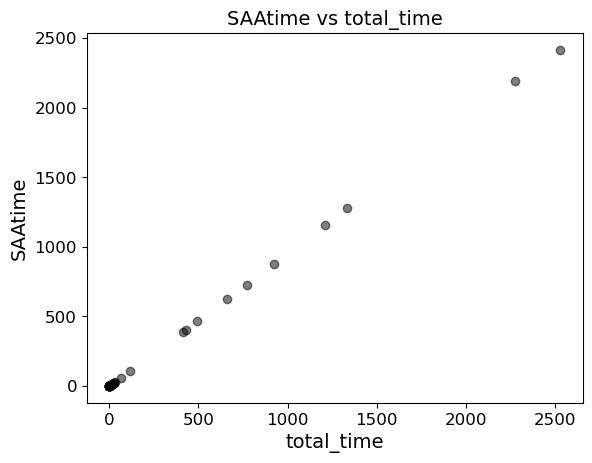

In [121]:
import matplotlib.pyplot as plt

df_Strat4_1000 = pd.concat([df30, df40, df50], ignore_index=True)

plt.scatter(df_Strat4_1000['total_time'], df_Strat4_1000['total_SAA'], color='black', marker='o',alpha=0.5)
plt.title('SAAtime vs total_time', fontsize=14)
plt.xlabel('total_time', fontsize=14)
plt.ylabel('SAAtime', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.show()
plt.savefig("mainStrat4_total_time_vs_SAAtime.png")

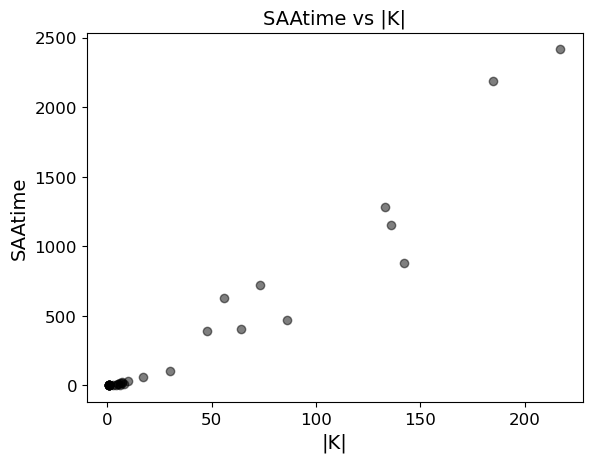

In [119]:
import matplotlib.pyplot as plt
plt.scatter(df_Strat4_1000['K'], df_Strat4_1000['total_SAA'], color='black', marker='o',alpha=0.5)
plt.title('SAAtime vs |K|', fontsize=14)
plt.xlabel('|K|', fontsize=14)
plt.ylabel('SAAtime', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.show()
plt.savefig("mainStrat4_SAAtime_vs_K.png")

In [8]:
df_Strat4_1000

,iiter,total_time,b,ObjVal,x_sol,Ins
0,-1,0.402595,10,330.000000,[ 0 1 2 3 4 5 6 39 75 172],8
1,-1,0.391035,10,330.000000,[ 0 1 2 3 4 5 6 39 75 172],8
2,-1,122.916845,10,371.078125,[ 0 1 2 3 127 134 146 155 161 163],9
3,-1,124.183239,10,371.078125,[ 0 1 2 3 127 134 146 155 161 163],9
4,10,528.015625,[ 2 3 76 78 114 129 131 151 173 185],168.000000,644.110943,70
5,-1,1.318296,10,688.000000,[ 0 1 2 25 38 52 67 70 98 153],10
6,-1,1.199593,10,688.000000,[ 0 1 2 25 38 52 67 70 98 153],10
7,10,112.000000,[ 0 1 2 3 4 5 6 7 8 17],1.000000,0.619513,13
8,10,366.191406,[ 1 3 59 65 83 91 149 162 176 193],24.000000,62.83506,17
9,10,505.000000,[ 0 1 2 3 4 5 6 7 98 116],1.000000,0.67534,28


In [128]:
df_Strat4_5000

,iiter,total_time,b,ObjVal,x_sol,Ins
0,-1,0.387277,10,585.000000,[ 0 1 2 3 4 5 6 7 44 225],8
1,-1,75.194311,10,497.000000,[ 0 2 4 57 165 170 253 272 289 299],2
2,-1,1219.019841,10,509.402508,[ 0 1 40 59 90 205 243 254 277 320],1
3,-1,1206.936786,10,486.491119,[ 0 1 5 17 106 174 234 249 292 299],10
4,-1,233.581529,10,264.234375,[ 0 1 2 3 4 5 118 236 250 292],6
5,-1,0.373258,10,168.000000,[ 0 1 2 3 4 5 6 200 234 260],7


In [131]:
print(len(df_Strat4_5000))
(df_Strat4_5000.total_time.sum()+(10-len(df_Strat4_5000))*3600)/10

6


1713.5493001937866

In [133]:
merged_df = df_Strat4_1000.merge(df_Strat4_5000, on=['Ins'], how='outer')
merged_df = merged_df.merge(df_Strat4_10000, on=['Ins'], how='outer')

In [123]:
merged_df.iloc[:,[4, 10, 15]]

,x_sol_x,x_sol_y,x_sol
0,[ 1 4 77 128 244 270 283 352 427 472],[ 1 4 77 128 244 270 283 352 427 472],NaN
1,[ 2 117 119 137 144 145 148 201 232 495],[ 2 117 119 137 144 145 148 201 232 495],[ 2 117 119 137 144 145 148 201 232 495]
2,[ 0 1 16 42 50 72 167 190 227 299],[ 0 1 16 42 50 72 167 190 227 299],[ 0 1 16 42 50 72 167 190 227 299]
3,[ 0 1 2 22 26 190 228 267 417 436],[ 0 1 2 22 26 190 228 267 417 436],[ 0 1 2 22 26 190 228 267 417 436]
4,[ 0 1 2 10 45 65 247 314 452 461],[ 0 1 2 10 45 65 247 314 452 461],[ 0 1 2 10 45 65 247 314 452 461]
5,[ 0 1 2 3 4 5 6 7 32 156],[ 0 1 2 3 4 5 6 7 32 156],[ 0 1 2 3 4 5 6 7 32 156]
6,[ 0 6 16 28 159 164 273 311 347 420],NaN,[ 0 6 16 28 159 164 273 311 347 420]
